# MSIN0167: Data Visualisation - Group Assignment: Part A
## Team 12
- Stephanie Christodoulou - Student ID: 20024451
- Barbara Gonzalez Silva - Student ID: 20134069
- Laura Cechnicka - Student ID: 19070766
- Raghav Gupta - Student ID: 23196602



In this notebook, we perform an explanatory analysis of the OneSky dataset to investigate and explore the relationships between the features. We produce maps and plots to visualise our findings.

## About the OneSky Dataset
The OneSky has developed an affordable air quality monitoring device which measures PM2.5, VOC, temperature and humidity as well as taking a GPS location.
Using a USB plug and a play device, clients in construction, rail and social housing sends the data via the cellular network for analysis and reporting.

# Website
- Website Link: https://codepen.io/Stephanie-Christodoulou/full/LYvYWjK
#### Assumptions and Limitations:
- We assume the website is for 13'-15' laptop screens and is viewd on full mode on full size windows

## Table of Contents

* [Data Wrangling](#data-wrangling)
    * [Initial Data Analysis](#initial-analysis)
    * [Data Cleaning](#data-cleaning)
* [Exploratory Data Analysis](#EDA)
    * [Descriptive Summary of Numerical Variables](#summary-numerical-variables)
    * [Descriptive Summary of Categorical Variables](#summary-categorical-variables)
    * [Distribution of Numerical Variables](#distribution-numerical-variables)
    * [Distribution of Numerical Variables](#distribution-numerical-variables)
    * [Checking for Outliers](#checking-outliers)
    * [Distribution of Data Over Time](#distribution-over-time)
        * [Distribution of Continuous Variables by Hour of Day](#distribution-by-day)
        * [Distribution of Continuous Variables by Month of Year](#distribution-by-month)
    * [Feature Correlation](#feature-correlation)
        * [Exploring the Relationship Between Highly Correlated Variables](#correlation-scatter-plot)
* [Presenting the Data](#data-presenting)
    * [Selected static charts](#static-charts)
    * [Interactive charts](#interactive-charts)
* [Conclusion](#conclusion)

## Data Wrangling <a class="anchor" id="data-wrangling"></a>

In [ ]:
# ## For G-drive
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
!pip install folium --user

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import matplotlib
import seaborn as sns
import folium
from folium.plugins import HeatMap
import requests
from urllib.request import urlopen
import plotly
import plotly.express as px
import plotly.graph_objs as go
import plotly.tools as tls

In [ ]:
# notebook customisations
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = '14'

In [ ]:
# read dataset from G-drive folder
# df = pd.read_csv(open('drive/MyDrive/Data Visualisation 1/Notebooks/OneSky_dataset.csv'))

In [ ]:
#read dataset from local folder
df = pd.read_csv(open('OneSKy_dataset.csv'))

### Initial Data Analysis <a class="anchor" id="initial-analysis"></a>

In [ ]:
df.head()

,id,device_id,reading_time,pm25,db,co2,voc,no2,co,no,...,humidity,temprature,pressure,battery,signal,sv,ps,latitude,longitude,message_time
0,10501256,E831CD8471EC,2023-10-09 07:26:02.000,9.0,51.0,0.0,176.0,0.0,0.0,0.0,...,45.0,24.0,1006.0,4060.0,11,0.01.19,True,",",",",2023-09-10 08:25:23.000
1,10501259,E831CD8471EC,2023-10-09 07:29:02.000,10.0,53.0,0.0,188.0,0.0,0.0,0.0,...,46.0,24.0,1006.0,4060.0,11,0.01.19,True,",",",",2023-09-10 08:25:23.000
2,10501261,E831CD8471EC,2023-10-09 07:31:02.000,10.0,56.0,0.0,191.0,0.0,0.0,0.0,...,46.0,24.0,1006.0,4060.0,11,0.01.19,True,",",",",2023-09-10 08:25:47.000
3,10501264,E831CD8471EC,2023-10-09 07:34:02.000,9.0,56.0,0.0,181.0,0.0,0.0,0.0,...,46.0,25.0,1007.0,4067.0,11,0.01.19,True,",",",",2023-09-10 08:25:47.000
4,10501265,E831CD8471EC,2023-10-09 07:35:02.000,9.0,56.0,0.0,178.0,0.0,0.0,0.0,...,46.0,25.0,1007.0,4064.0,11,0.01.19,True,",",",",2023-09-10 08:26:11.000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58767 entries, 0 to 58766
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            58767 non-null  int64  
 1   device_id     58767 non-null  object 
 2   reading_time  58767 non-null  object 
 3   pm25          57835 non-null  float64
 4   db            57835 non-null  float64
 5   co2           57835 non-null  float64
 6   voc           57835 non-null  float64
 7   no2           57835 non-null  float64
 8   co            57835 non-null  float64
 9   no            57835 non-null  float64
 10  pm1           57835 non-null  float64
 11  pm10          57835 non-null  float64
 12  humidity      57835 non-null  float64
 13  temprature    57835 non-null  float64
 14  pressure      57835 non-null  float64
 15  battery       57835 non-null  float64
 16  signal        58767 non-null  int64  
 17  sv            58767 non-null  object 
 18  ps            58767 non-nu

In [ ]:
df.describe()

,id,pm25,db,co2,voc,no2,co,no,pm1,pm10,humidity,temprature,pressure,battery,signal
count,5.876700e+04,57835.000000,57835.000000,57835.0,57835.000000,57835.0,57835.0,57835.0,57835.000000,57835.000000,57835.000000,57835.000000,57835.000000,57835.000000,58767.000000
mean,8.027048e+06,32.673053,44.255883,0.0,119.915155,0.0,0.0,0.0,29.638126,34.293473,63.947990,16.435377,1004.393395,3939.633872,15.343322
std,2.759487e+06,89.527772,17.590549,0.0,107.124277,0.0,0.0,0.0,83.483788,91.102089,17.317447,8.688960,10.904431,196.920988,4.078554
min,8.636730e+05,0.000000,0.000000,0.0,1.000000,0.0,0.0,0.0,0.000000,0.000000,11.000000,-5.000000,972.000000,3401.000000,2.000000
25%,6.564905e+06,3.000000,38.000000,0.0,45.000000,0.0,0.0,0.0,2.000000,3.000000,50.000000,10.000000,997.000000,3845.000000,13.000000
50%,6.852040e+06,6.000000,46.000000,0.0,97.000000,0.0,0.0,0.0,4.000000,7.000000,66.000000,17.000000,1005.000000,4052.000000,16.000000
75%,1.052948e+07,12.000000,56.000000,0.0,146.000000,0.0,0.0,0.0,10.000000,14.000000,79.000000,24.000000,1012.000000,4071.000000,18.000000
max,1.055877e+07,802.000000,90.000000,0.0,500.000000,0.0,0.0,0.0,745.000000,820.000000,98.000000,47.000000,1030.000000,4147.000000,24.000000


In [ ]:
df.count()

id              58767
device_id       58767
reading_time    58767
pm25            57835
db              57835
co2             57835
voc             57835
no2             57835
co              57835
no              57835
pm1             57835
pm10            57835
humidity        57835
temprature      57835
pressure        57835
battery         57835
signal          58767
sv              58767
ps              58767
latitude        58767
longitude       58767
message_time    58767
dtype: int64

It's important to highlight that the monitors do not measure gas levels; the CO2, NO2, etc. these columns consistently display zero as the reading.

Therefore, the primary emphasis of the analysis centers around particle size (PM25/1/10), humidity, VOC, temperature, and pressure.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58767 entries, 0 to 58766
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            58767 non-null  int64  
 1   device_id     58767 non-null  object 
 2   reading_time  58767 non-null  object 
 3   pm25          57835 non-null  float64
 4   db            57835 non-null  float64
 5   co2           57835 non-null  float64
 6   voc           57835 non-null  float64
 7   no2           57835 non-null  float64
 8   co            57835 non-null  float64
 9   no            57835 non-null  float64
 10  pm1           57835 non-null  float64
 11  pm10          57835 non-null  float64
 12  humidity      57835 non-null  float64
 13  temprature    57835 non-null  float64
 14  pressure      57835 non-null  float64
 15  battery       57835 non-null  float64
 16  signal        58767 non-null  int64  
 17  sv            58767 non-null  object 
 18  ps            58767 non-nu

### Data Cleaning <a class="anchor" id="data-cleaning"></a>

In [ ]:
#Changing the `temprature` column to `temp`
df = df.rename(columns={'temprature': 'temp'})

In [ ]:
#Converting `reading_time` and `message_time` columns from `object` to datetime type
df[['reading_time', 'message_time']] = df[['reading_time', 'message_time']].apply(pd.to_datetime)

We observe 932 missing values for (pm25, db, co2, voc, no2, co, no, pm1, pm10, humidity, templ, presssure,battery) out of 58767 entries.

We have chosen not drop these missing values from the original dataset for the purpose of our analysis.

In [ ]:
# Check for missing / null values in the dataset
print("Total missing values per column:")
df.isna().sum()

Total missing values per column:


id                0
device_id         0
reading_time      0
pm25            932
db              932
co2             932
voc             932
no2             932
co              932
no              932
pm1             932
pm10            932
humidity        932
temp            932
pressure        932
battery         932
signal            0
sv                0
ps                0
latitude          0
longitude         0
message_time      0
dtype: int64

## Exploratory Data Analysis <a class="anchor" id="EDA"></a>

### Descriptive Summary of Numerical Variables <a class="anchor" id="summary-numerical-variables"></a>

In [ ]:
# check for statistical description of all numerical variables
df.describe().style.background_gradient()

,id,pm25,db,co2,voc,no2,co,no,pm1,pm10,humidity,temp,pressure,battery,signal
count,58767.000000,57835.000000,57835.000000,57835.000000,57835.000000,57835.000000,57835.000000,57835.000000,57835.000000,57835.000000,57835.000000,57835.000000,57835.000000,57835.000000,58767.000000
mean,8027047.868787,32.673053,44.255883,0.000000,119.915155,0.000000,0.000000,0.000000,29.638126,34.293473,63.947990,16.435377,1004.393395,3939.633872,15.343322
std,2759486.888825,89.527772,17.590549,0.000000,107.124277,0.000000,0.000000,0.000000,83.483788,91.102089,17.317447,8.688960,10.904431,196.920988,4.078554
min,863673.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,-5.000000,972.000000,3401.000000,2.000000
25%,6564905.000000,3.000000,38.000000,0.000000,45.000000,0.000000,0.000000,0.000000,2.000000,3.000000,50.000000,10.000000,997.000000,3845.000000,13.000000
50%,6852040.000000,6.000000,46.000000,0.000000,97.000000,0.000000,0.000000,0.000000,4.000000,7.000000,66.000000,17.000000,1005.000000,4052.000000,16.000000
75%,10529475.000000,12.000000,56.000000,0.000000,146.000000,0.000000,0.000000,0.000000,10.000000,14.000000,79.000000,24.000000,1012.000000,4071.000000,18.000000
max,10558767.000000,802.000000,90.000000,0.000000,500.000000,0.000000,0.000000,0.000000,745.000000,820.000000,98.000000,47.000000,1030.000000,4147.000000,24.000000


### Descriptive Summary of Categorical Variables <a class="anchor" id="summary-categorical-variables"></a>

In [ ]:
df.describe(include='object')

,device_id,sv,latitude,longitude
count,58767,58767,58767,58767
unique,5,2,230,124
top,E831CD848A1C,0.01.18,",",","
freq,35729,46741,14825,14825


Looking closer at device_id, we find that there are 5 unique devices that have been used for monitoring these data

In [ ]:
set(df['device_id'])

{'1097BD0B52A0',
 '4C11AEADF0DC',
 'E831CD8442E4',
 'E831CD8471EC',
 'E831CD848A1C'}

### Distribution of Numerical Variables <a class="anchor" id="distribution-numerical-variables"></a>

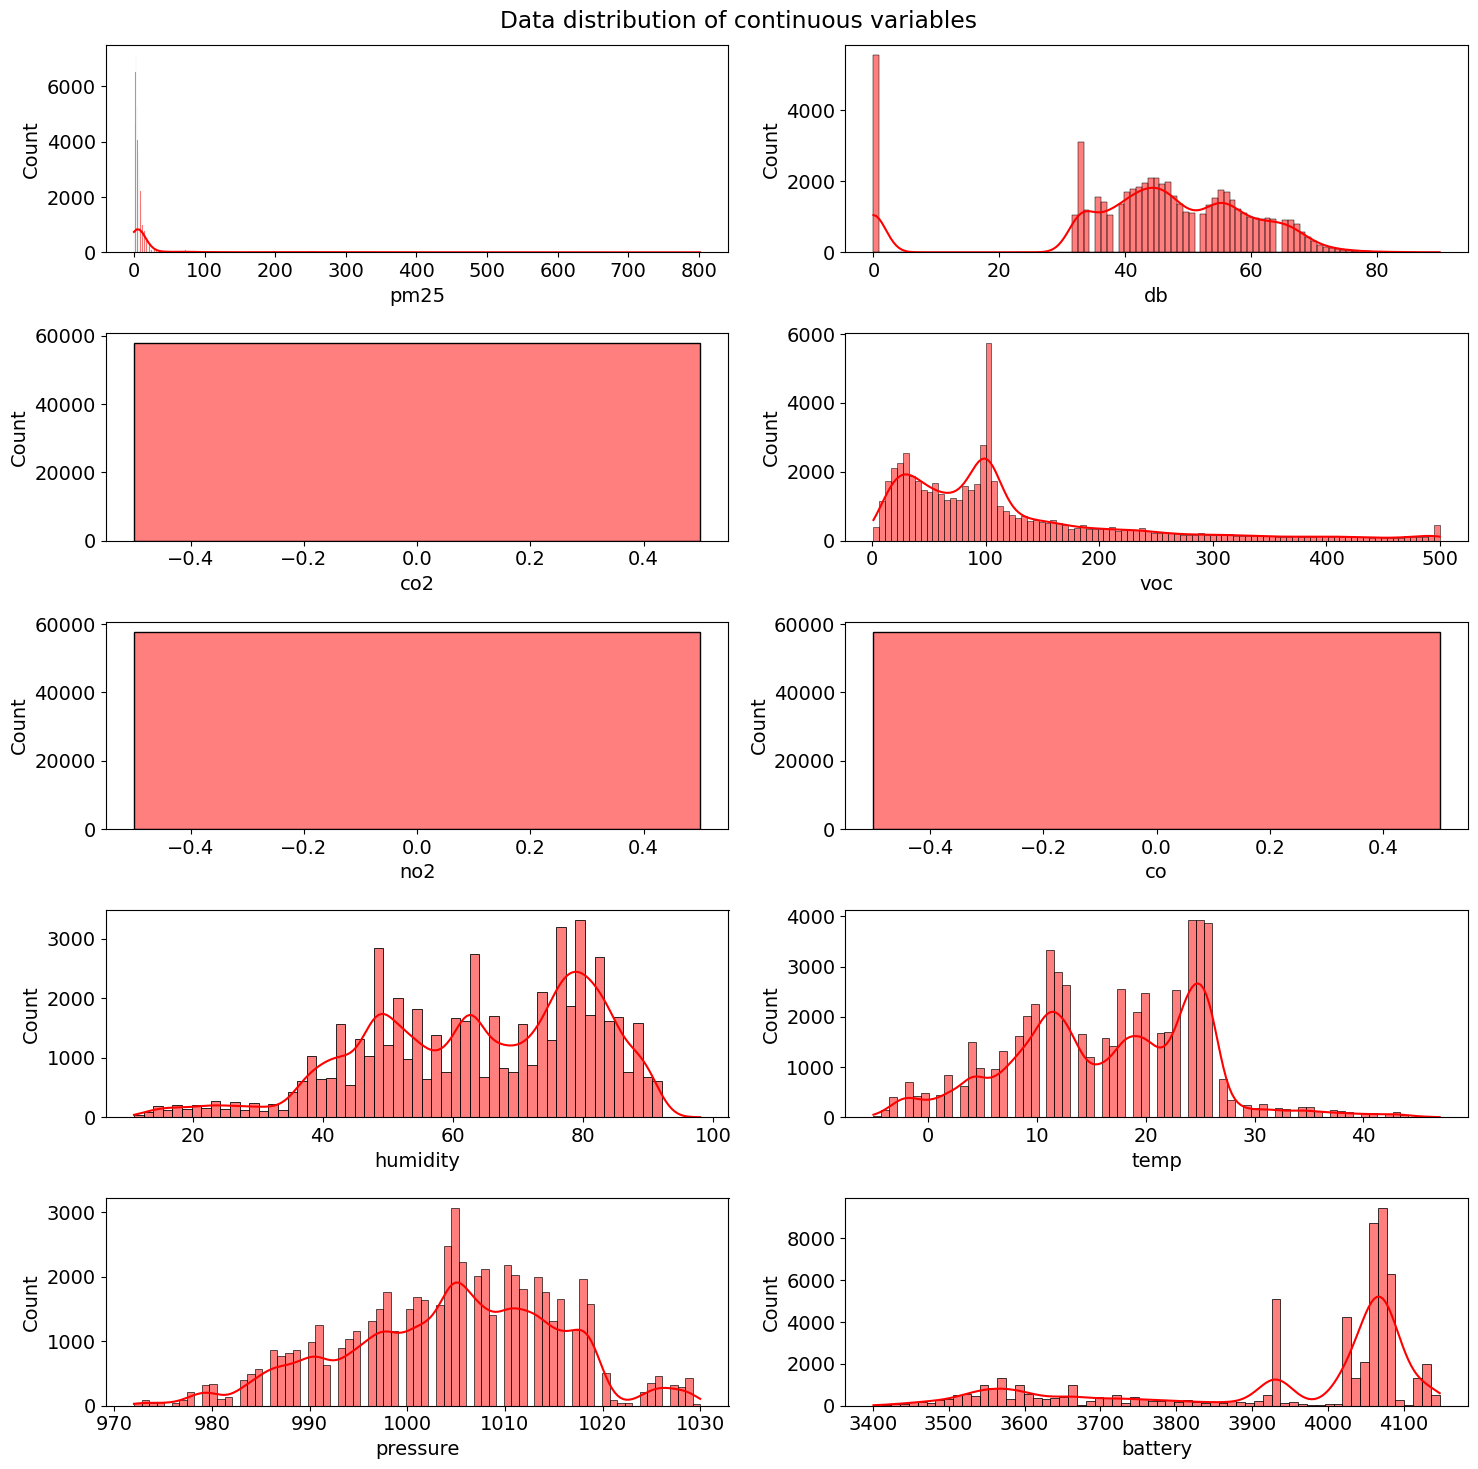

In [ ]:
numerical_features = ['pm25', 'db', 'co2', 'voc', 'no2', 'co', 'humidity', 'temp', 'pressure', 'battery']
# Histograms
plt.figure(figsize=(15, 15))
for i, col in enumerate(df[numerical_features].columns):
    plt.rcParams['axes.facecolor'] = 'white'
    ax = plt.subplot(5,2, i+1)
    sns.histplot(data=df, x=col, ax=ax, kde=True, color="red")
plt.suptitle('Data distribution of continuous variables')
plt.tight_layout()
plt.show()

- The gas level columns: CO2, NO2, CO, consistently display zero readings
- Pressure follows a normal distribution
- Other features follow a skwed distribution

### Checking for Outliers <a class="anchor" id="checking-outliers"></a>

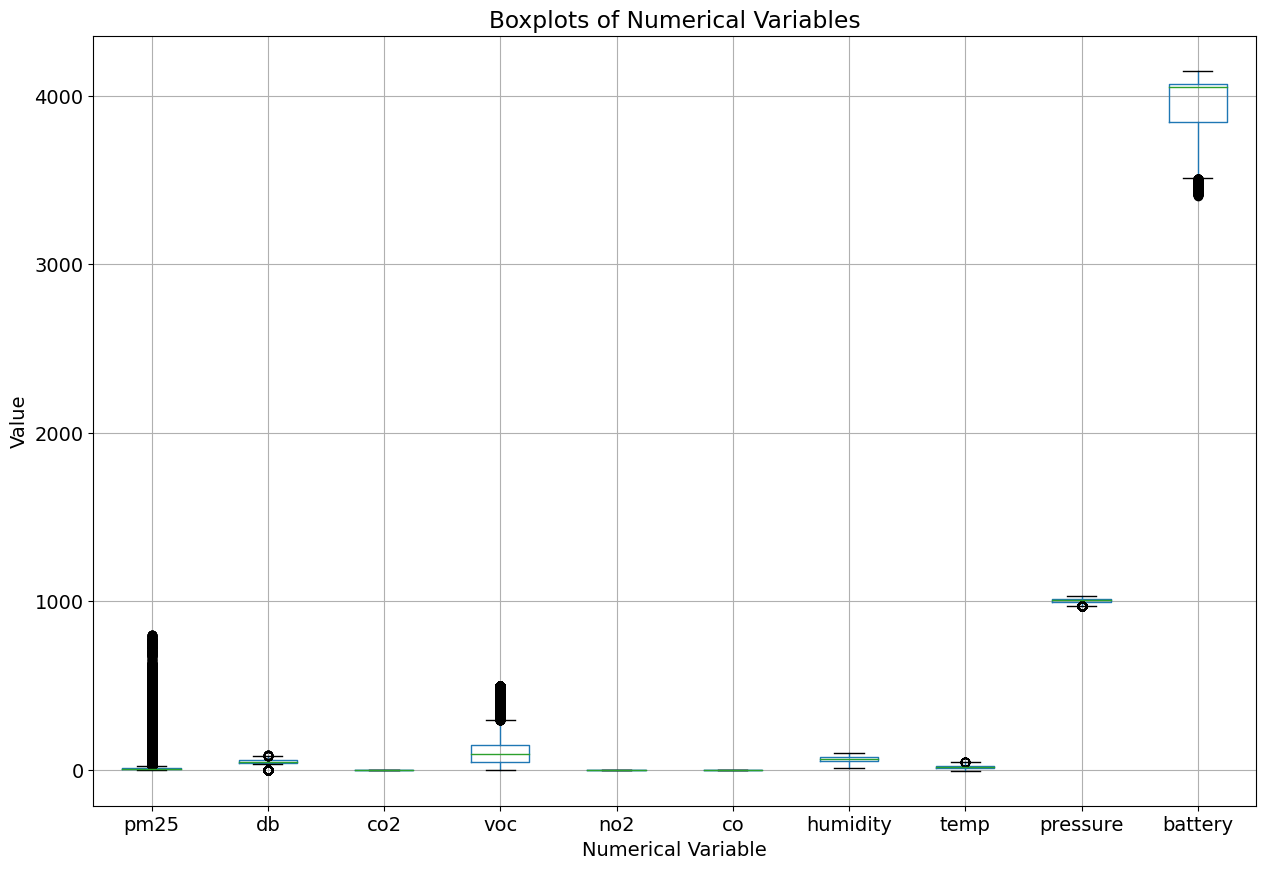

In [ ]:
plt.figure(figsize=(15, 10))
df[numerical_features].boxplot()
plt.xlabel("Numerical Variable")
plt.ylabel("Value")
plt.title("Boxplots of Numerical Variables")
plt.show()

- Outliers have been detected for values pm25, voc and battery  

### Distribution of Data Over Time  <a class="anchor" id="distribution-over-time"></a>

Here we use a histogram to better understand the distribution of the reading times over the measurement period

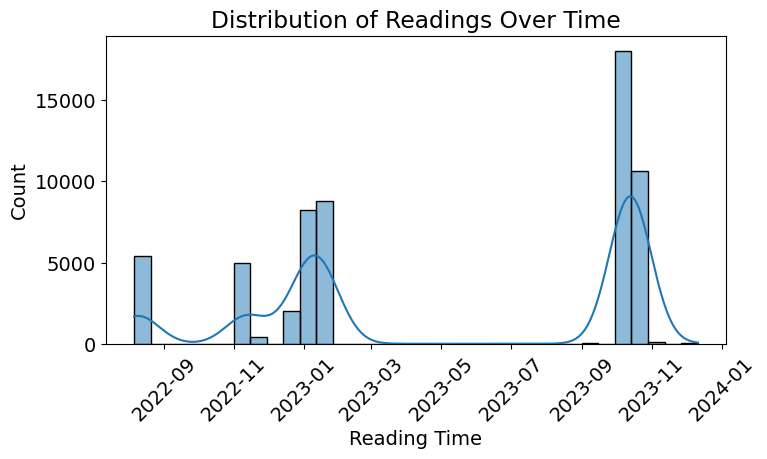

In [ ]:
sns.histplot(df["reading_time"], kde=True)
# Rotate x-axis labels
plt.xticks(rotation=45)
plt.xlabel("Reading Time")
plt.ylabel("Count")
plt.title("Distribution of Readings Over Time")
plt.show()

- We observe no readings for the periods: 09/2022 to 11/2022 and 03/2023 to 09/2023


Now using lineplots, we try to better understand the distribution of continuous variables

In [ ]:
# Extracting time specific details
df["hour"] = df["reading_time"].dt.hour
df["day"] = df["reading_time"].dt.day
df["weekday"] = df["reading_time"].dt.weekday
df["month"] = df["reading_time"].dt.month

#### Distribution of Continuous Variables by Hour of Day <a class="anchor" id="distribution-by-day"></a>

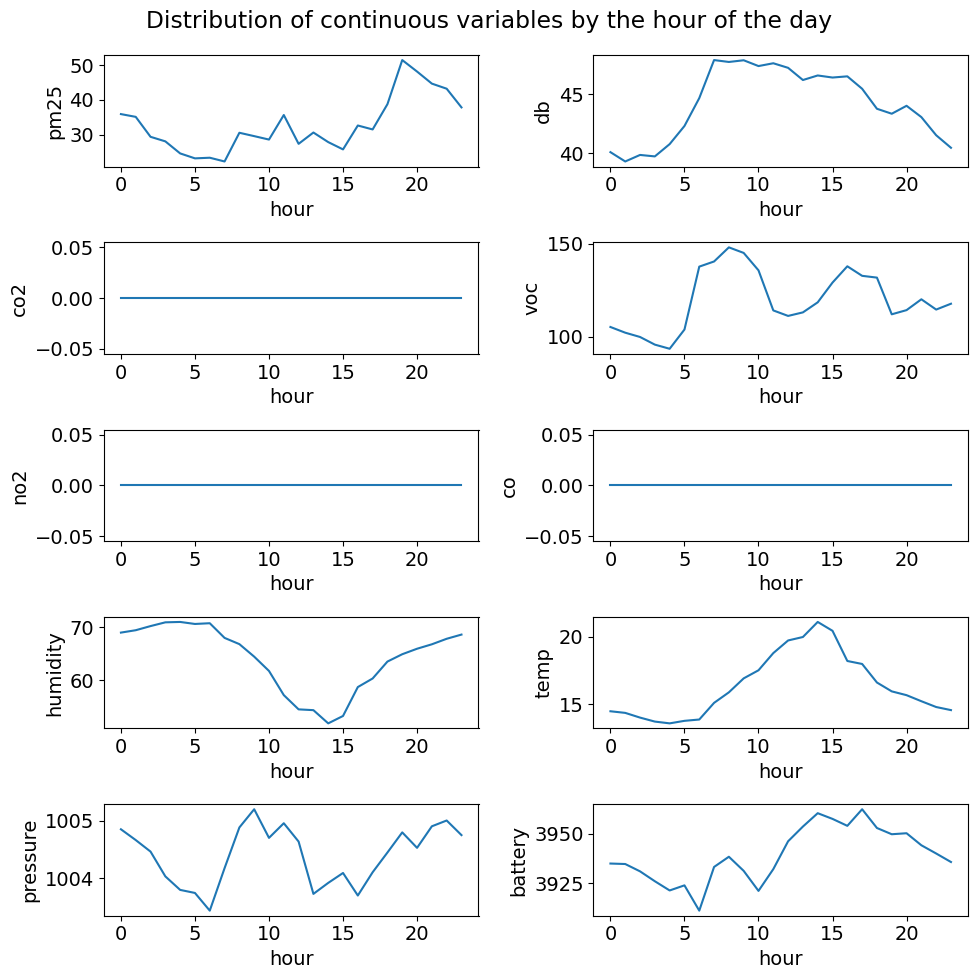

In [ ]:
fig_1 = plt.figure(figsize=(10, 10))
for i, col in enumerate(df[numerical_features].columns):
    plt.rcParams['axes.facecolor'] = 'white'
    ax = plt.subplot(5,2, i+1)
    sns.lineplot(data=df, x="hour", y=col, ax=ax, errorbar=None)
plt.suptitle('Distribution of continuous variables by the hour of the day')
plt.tight_layout()

#### Distribution of Continuous Variables by Month of Year <a class="anchor" id="distribution-by-month"></a>

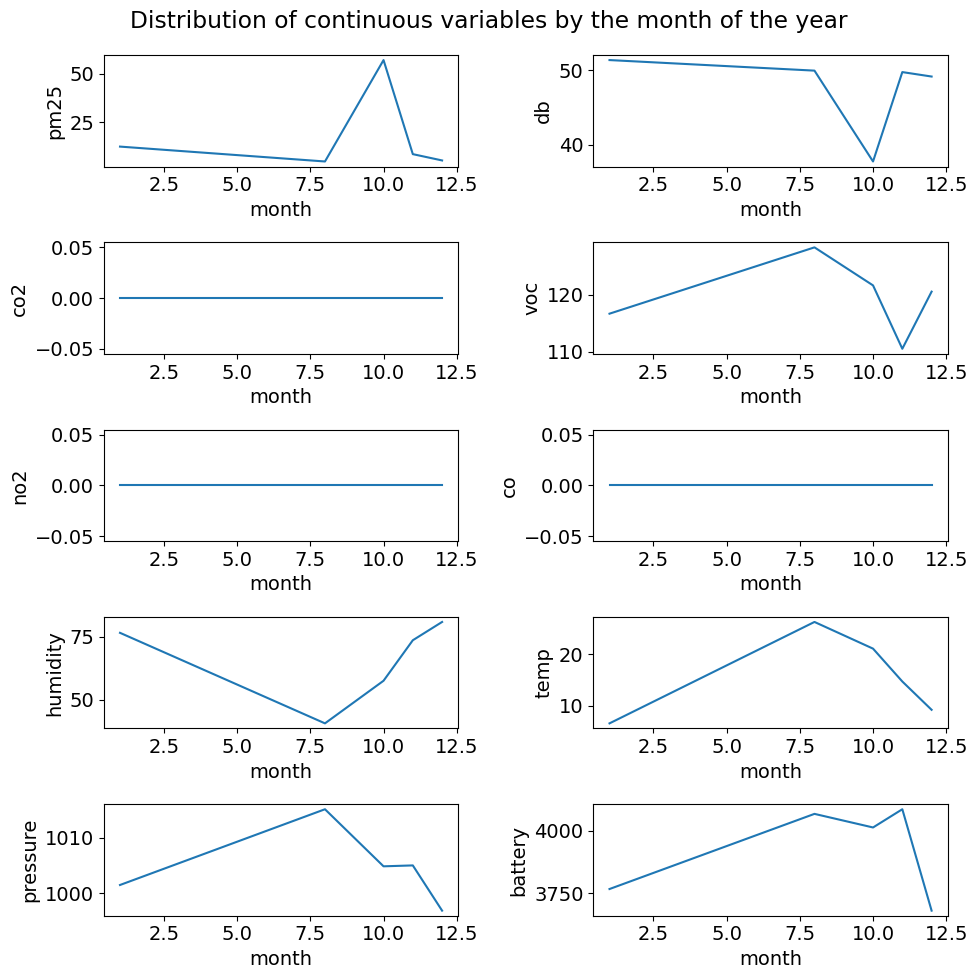

In [ ]:
plt.figure(figsize=(10, 10))
for i, col in enumerate(df[numerical_features].columns):
    plt.rcParams['axes.facecolor'] = 'white'
    ax = plt.subplot(5,2, i+1)
    sns.lineplot(data=df, x="month", y=col, ax=ax, errorbar=None)
plt.suptitle('Distribution of continuous variables by the month of the year')
plt.tight_layout()

### Feature Correlation <a class="anchor" id="feature-correlation"></a>

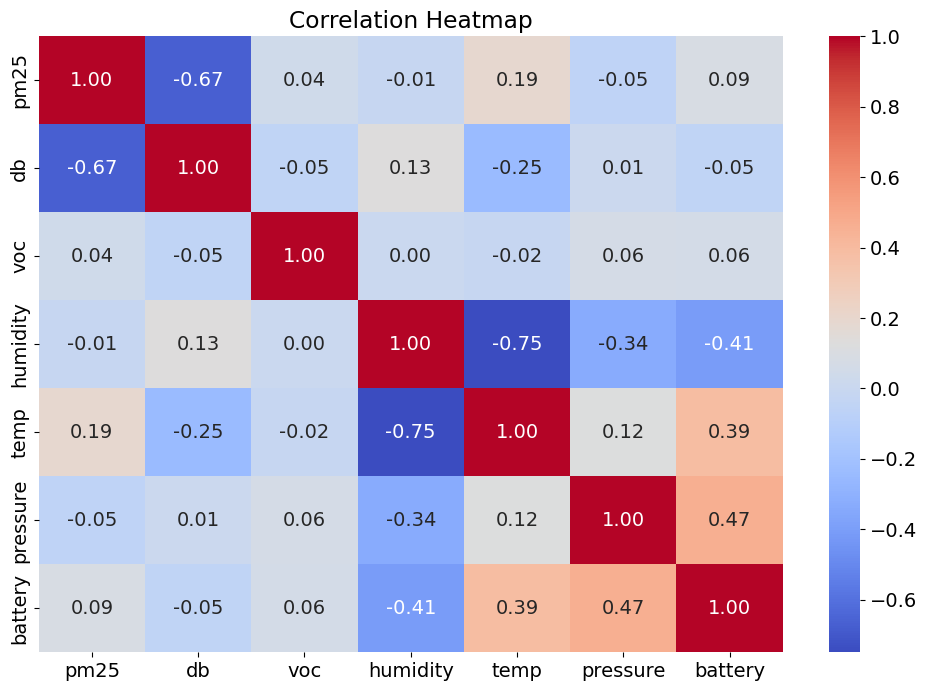

In [ ]:
numerical_features_without_zero_values = ['pm25', 'db', 'voc', 'humidity', 'temp', 'pressure', 'battery']
correlation_matrix = df[numerical_features_without_zero_values].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

- humidity & temperature are highly correlated
- db and pm25 are highly correlated
- battery and humidity/temperature/pressure are moderately correlated, maybe when battery is low it tends to record with less accuracy

#### Exploring the Relationship Between Highly Correlated Features <a class="anchor" id="correlation-scatter-plot"></a>

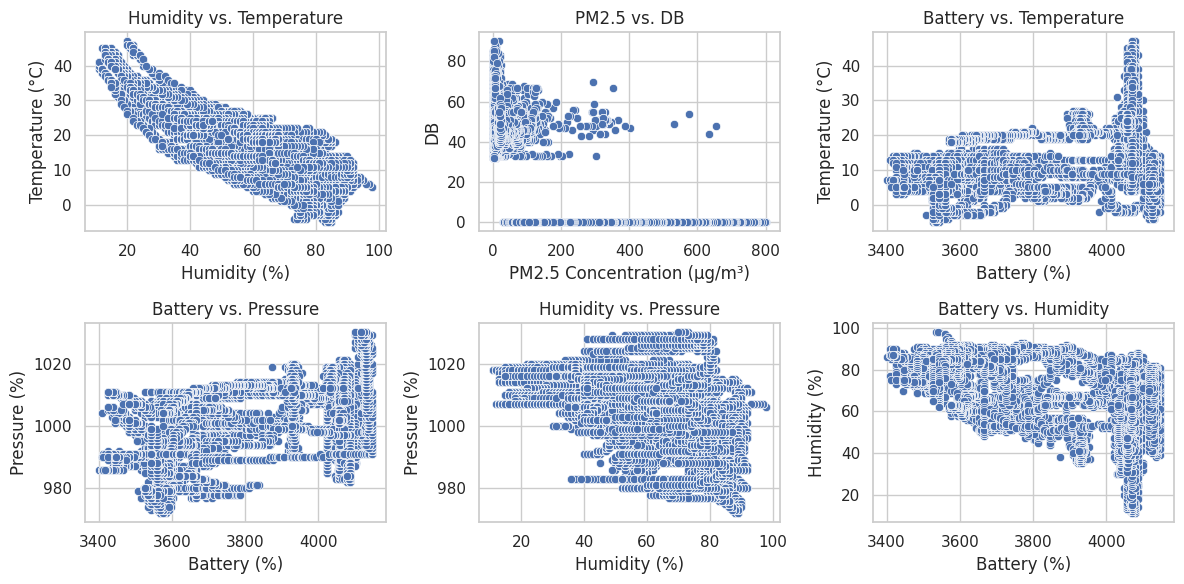

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))  # Adjust figsize for better viewing

# Plot data on each subplot
sns.scatterplot(data=df, x="humidity", y="temp", ax=axes[0, 0])
axes[0, 0].set_title("Humidity vs. Temperature")
axes[0, 0].set_xlabel("Humidity (%)")
axes[0, 0].set_ylabel("Temperature (°C)")

sns.scatterplot(data=df, x="pm25", y="db", ax=axes[0, 1])
axes[0, 1].set_title("PM2.5 vs. DB")
axes[0, 1].set_xlabel("PM2.5 Concentration (μg/m³)")
axes[0, 1].set_ylabel("DB")

sns.scatterplot(data=df, x="battery", y="temp", ax=axes[0, 2])
axes[0, 2].set_title("Battery vs. Temperature")
axes[0, 2].set_xlabel("Battery (%)")
axes[0, 2].set_ylabel("Temperature (°C)")

sns.scatterplot(data=df, x="battery", y="pressure", ax=axes[1, 0])
axes[1, 0].set_title("Battery vs. Pressure")
axes[1, 0].set_xlabel("Battery (%)")
axes[1, 0].set_ylabel("Pressure (%)")

sns.scatterplot(data=df, x="humidity", y="pressure", ax=axes[1, 1])
axes[1, 1].set_title("Humidity vs. Pressure")
axes[1, 1].set_xlabel("Humidity (%)")
axes[1, 1].set_ylabel("Pressure (%)")


sns.scatterplot(data=df, x="battery", y="humidity", ax=axes[1, 2])
axes[1, 2].set_title("Battery vs. Humidity")
axes[1, 2].set_xlabel("Battery (%)")
axes[1, 2].set_ylabel("Humidity (%)")




# Adjust layout
plt.tight_layout()

plt.show()

- humidity and temperature seem to have a linear relationship as expected
- other variables do not seem to have a linear realtionship

## Presenting the data <a class="anchor" id="data-presenting"></a>

After this exploratory analysis, we now dissect the data to present the relationships between different variables through various static and interactive charts tools such as scatterplots, box-plots, heatmaps and map-plots.

We have explored themes such as noise pollution, the relationship between air and noise pollution, the interaction between different pollution markers and the geographical variation in pm2.5 & voc levels.  

### Selected Static Charts <a class="anchor" id="static-charts"></a>

We first plot a scatterplot to understand the capture of noise levels by different devices. By adding VOC to this graph, we get a sense of there being a relationship between noise and air pollution.

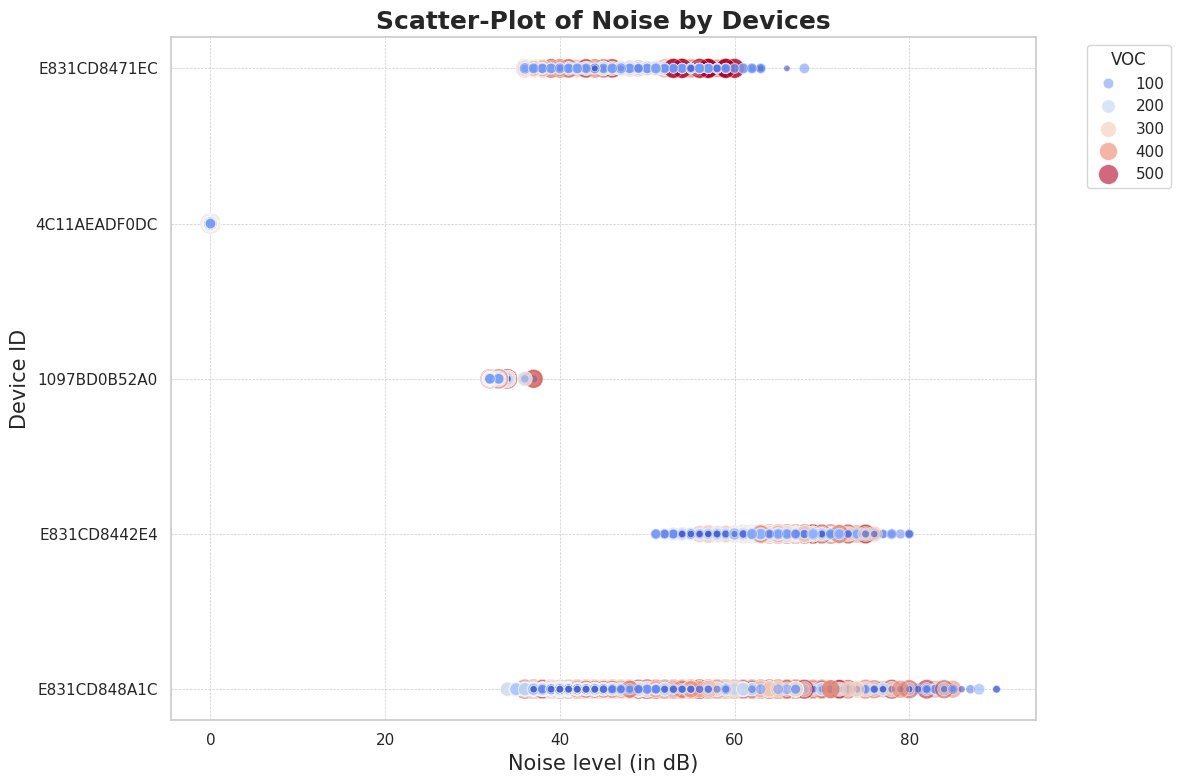

In [ ]:
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")
scatter = sns.scatterplot(x='db', y='device_id', size='voc', hue='voc', data=df, palette='coolwarm', alpha=0.6, sizes=(20, 200))
plt.title('Scatter-Plot of Noise by Devices', fontsize=18, fontweight='bold')
plt.xlabel('Noise level (in dB)', fontsize=15)
plt.ylabel('Device ID', fontsize=15)
plt.legend(title='VOC', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

We shall now explore this relationship between air and noise pollution more deeply through iterations of a box-plot.

In [ ]:
#Slicing original dataset by dropping rows where pm2.5 and voc take null values
df_non_nulls = df.dropna(axis=0, subset={'pm25', 'voc'})
df_non_nulls.head() #code to check

,id,device_id,reading_time,pm25,db,co2,voc,no2,co,no,...,signal,sv,ps,latitude,longitude,message_time,hour,day,weekday,month
0,10501256,E831CD8471EC,2023-10-09 07:26:02,9.0,51.0,0.0,176.0,0.0,0.0,0.0,...,11,0.01.19,True,",",",",2023-09-10 08:25:23,7,9,0,10
1,10501259,E831CD8471EC,2023-10-09 07:29:02,10.0,53.0,0.0,188.0,0.0,0.0,0.0,...,11,0.01.19,True,",",",",2023-09-10 08:25:23,7,9,0,10
2,10501261,E831CD8471EC,2023-10-09 07:31:02,10.0,56.0,0.0,191.0,0.0,0.0,0.0,...,11,0.01.19,True,",",",",2023-09-10 08:25:47,7,9,0,10
3,10501264,E831CD8471EC,2023-10-09 07:34:02,9.0,56.0,0.0,181.0,0.0,0.0,0.0,...,11,0.01.19,True,",",",",2023-09-10 08:25:47,7,9,0,10
4,10501265,E831CD8471EC,2023-10-09 07:35:02,9.0,56.0,0.0,178.0,0.0,0.0,0.0,...,11,0.01.19,True,",",",",2023-09-10 08:26:11,7,9,0,10


In [ ]:
#creating a new slice to focus on pm2.5 and noise (dB)
pm25_db = df_non_nulls[['device_id','reading_time', 'pm25', 'db']]
pm25_db.head() #code to check

,device_id,reading_time,pm25,db
0,E831CD8471EC,2023-10-09 07:26:02,9.0,51.0
1,E831CD8471EC,2023-10-09 07:29:02,10.0,53.0
2,E831CD8471EC,2023-10-09 07:31:02,10.0,56.0
3,E831CD8471EC,2023-10-09 07:34:02,9.0,56.0
4,E831CD8471EC,2023-10-09 07:35:02,9.0,56.0


In [ ]:
pm25_db_copy = pm25_db.copy() #creating a copy to avoid slice a copy warning
pm25_db_copy['db'].isnull().sum() #checking for null values within data-slice

0

We shall now create a new column in the database to classify pm2.5 levels into 'high' and 'low'

In [ ]:
# Categorizing pm2.5 values based on defined criterion
pm25_db_copy.pm25.apply(lambda x: 'high' if x > 20 else 'low')
#Creating a new categorical column to classify pm2.5 readings into high or low
pm25_db_copy['pm25_class'] = pm25_db_copy['pm25'].apply(lambda x: 'high' if x > 20 else 'low')
pm25_low = pm25_db_copy[pm25_db_copy['pm25_class'] == 'low'] #slicing further to find only low PM2.5 levels
pm25_high = pm25_db_copy[pm25_db_copy['pm25_class'] == 'high'] #slicing further to find only high PM2.5 levels

We shall now look at the descriptive statistics for the categorized subsets

In [ ]:
pm25_low.describe()
pm25_high.describe()

,pm25,db
count,8957.000000,8957.000000
mean,179.291169,17.787206
std,161.912043,23.188921
min,21.000000,0.000000
25%,47.000000,0.000000
50%,119.000000,0.000000
75%,262.000000,43.000000
max,802.000000,83.000000


We see that the mean, standard deviation, max. and min. of noise levels (dB) vary significantly between high & low PM2.5 values. To visualise this relationship, we shall now create a box plot.

In [ ]:
# Creating a basic box plot of 'db' values by 'pm2.5_class'
fig_pm25_db = px.box(pm25_db_copy, x='pm25_class', y='db', title='Noise level by pm2.5 class')
fig_pm25_db.show()

We shall now build on this basic plot by changing the background and marker colour  

In [ ]:
fig_pm25_db.update_traces(marker=dict(color='purple'))  # Change marker color to purple
fig_pm25_db.update_layout(title='Noise level by pm2.5 class',
                  xaxis_title='pm2.5 Class',  # X-axis title
                  yaxis_title='db Values',  # Y-axis title
                  font=dict(family='Arial', size=16, color='black'),  # Customize font style
                  plot_bgcolor='pink',  # Set plot background color
                  showlegend=False,  # Show legend
                  legend=dict(x=0, y=1.0),  # Position legend
                  hovermode='closest'  # Set hover mode
                  )
fig_pm25_db.show()

To make the difference in variation of dB levels across high and low clearer, we shall enhance the trace lines

In [ ]:
for trace in fig_pm25_db.data:
    trace.marker.size = 6  # Set marker size
    trace.line.width = 4  # Set line thickness

# Update layout and styling options
fig_pm25_db.update_layout(title='Noise level by pm2.5 class',
                    xaxis_title='PM2.5 Level',  # X-axis title
                    yaxis_title='Noise level (in dB)',  # Y-axis title
                    font=dict(family='Arial', size=16, color='black'),  # Font style
                    plot_bgcolor='pink',  # Plot background color
                    showlegend=False,  # Show legend
                    hovermode='closest'  # Hover mode
                    )

fig_pm25_db.show()

We observe that within each plot there are some noteworthy observations. For low PM2.5 levels, there are some readings of noise levels that are unusually high and can be deemed outliers. For high PM2.5 levels, we observe that a significant proportion of the readings hover around 0.

We will try to highlight these idiosyncrasies using annotations.

In [ ]:
#Annotating within the figure

fig_pm25_db.add_annotation(xref='x', yref='y',
                     x=1, y=0,  # Coordinates for the annotation (adjust as needed)
                     text='Median = 0',  # Annotation text
                     showarrow=True, arrowhead=1, arrowcolor='black', arrowwidth=3, ax=50, ay=-50,
                     bordercolor='purple', borderwidth=2,
                     bgcolor='lightgrey',  # Red highlight color with opacity
                     font=dict(family='Arial', size=12, color='black'),  # Font style
                     )

fig_pm25_db.add_annotation(xref='x', yref='y',
                     x=0, y=85,  # Coordinates for the annotation (adjust as needed)
                     text='Outliers',  # Annotation text
                     showarrow=True, arrowhead=1, arrowcolor='black', arrowwidth=3, ax=50, ay=-50,
                     bordercolor='black', borderwidth=2,
                     bgcolor='lightgrey',  # Red highlight color with opacity
                     font=dict(family='Arial', size=12, color='black'),  # Font style
                     )

# Update layout and styling options
fig_pm25_db.update_layout(title='Noise Levels against PM2.5 Levels',
                    xaxis_title='PM2.5 Levels',  # X-axis title
                    yaxis_title='Noise Levels (in dB)',  # Y-axis title
                    font=dict(family='Arial', size=16, color='black'),  # Font style
                    plot_bgcolor='pink',  # Plot background color
                    showlegend=False,  # Show legend
                    hovermode='closest'  # Hover mode
                    )

fig_pm25_db.show()

As the last of our static charts, we will look to understand the interaction between the important pollution markers voc and pm2.5.

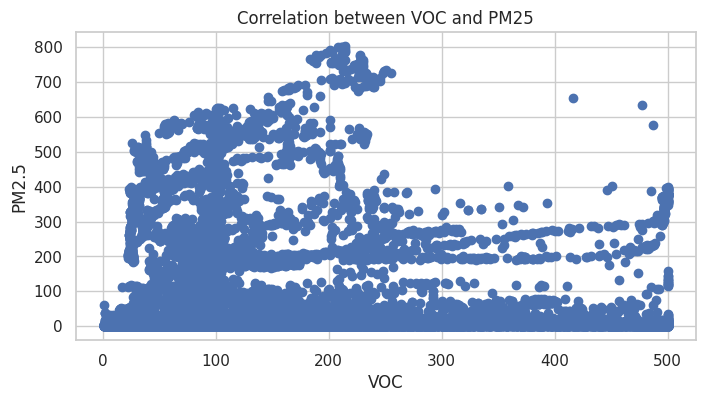

Correlation Coefficient: 0.03706889252554678


In [ ]:
# Select relevant columns (voc and pm25)
selected_data = df[['voc', 'pm25']]

# Drop rows with missing values
selected_data = selected_data.dropna()

# Plot the data
plt.scatter(selected_data['voc'], selected_data['pm25'])
plt.title('Correlation between VOC and PM25')
plt.xlabel('VOC')
plt.ylabel('PM2.5')
plt.show()

# Calculate correlation coefficient
correlation_coefficient = selected_data['voc'].corr(selected_data['pm25'])
print(f'Correlation Coefficient: {correlation_coefficient}')

We will now explore the theme of geographical variation in air and general pollution levels through the use of interactive charts.

### Interactive Charts <a class="anchor" id="interactive-charts"></a>

We start by manipulting and grouping the dataset by geographical locations.

In [ ]:
# empty geo-coordinates are marked by a ','
# extract all non-empty geo-coordinates
df_geo = df[df.latitude != ',']

In [ ]:
# get the number of specific geographical locations
len(set(df_geo.latitude))

229

By grouping the rows by latitude and longitude and taking the first member of the group, we can get the unique geographical locations in the dataset:

In [ ]:
# get the number of unique locations
df_geo.groupby(['latitude', 'longitude']).first()

,,id,device_id,reading_time,pm25,db,co2,voc,no2,co,no,...,pressure,battery,signal,sv,ps,message_time,hour,day,weekday,month
latitude,longitude,,,,,,,,,,,,,,,,,,,,,
51183870N,00156146W,10548445,4C11AEADF0DC,2023-10-15 12:00:04,112.0,0.0,0.0,94.0,0.0,0.0,0.0,...,1013.0,3786.0,7,0.01.19,False,2023-10-15 13:00:13,12,15,6,10
51185576N,00156580W,10552566,4C11AEADF0DC,2023-10-16 01:14:59,197.0,0.0,0.0,101.0,0.0,0.0,0.0,...,1011.0,3651.0,5,0.01.19,False,2023-10-16 01:14:59,1,16,0,10
51186165N,00156401W,10557012,4C11AEADF0DC,2023-10-16 13:49:04,103.0,0.0,0.0,100.0,0.0,0.0,0.0,...,1006.0,3603.0,5,0.01.19,False,2023-10-16 14:07:31,13,16,0,10
51186205N,00156434W,10513045,4C11AEADF0DC,2023-10-10 20:03:01,497.0,0.0,0.0,101.0,0.0,0.0,0.0,...,1003.0,4024.0,8,0.01.19,True,2023-10-10 21:00:10,20,10,1,10
51186213N,00156389W,10556255,4C11AEADF0DC,2023-10-16 12:14:04,88.0,0.0,0.0,103.0,0.0,0.0,0.0,...,1006.0,3603.0,8,0.01.19,False,2023-10-16 13:03:06,12,16,0,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51326696N,00010500W,10528016,E831CD8442E4,2023-10-12 19:00:01,8.0,63.0,0.0,128.0,0.0,0.0,0.0,...,1004.0,4052.0,23,0.01.18,True,2023-12-10 20:00:37,19,12,3,10
51326734N,00010606W,10520684,E831CD8442E4,2023-10-11 19:02:51,12.0,65.0,0.0,129.0,0.0,0.0,0.0,...,1005.0,4056.0,21,0.01.18,True,2023-11-10 20:00:37,19,11,2,10
51326748N,00010563W,10538945,E831CD8442E4,2023-10-14 06:00:05,3.0,61.0,0.0,120.0,0.0,0.0,0.0,...,1007.0,4048.0,22,0.01.18,True,2023-10-14 07:00:39,6,14,5,10


In [ ]:
df_geo_unique = df_geo.groupby(['latitude', 'longitude']).first()

In [ ]:
# reset the index to put latitude and longitude columns back
df_geo_unique = df_geo_unique.reset_index()

Examining the geographical columns reveals their representation as strings featuring an eight-digit number concluding with a compass point. This format requires conversion for compatibility with most mapping tools. To achieve this conversion, we employ the functions below. These functions remove the trailing letter, introduce a decimal point after the initial two digits, and transform the strings into floating-point numbers.

In [ ]:
def fix_latitude(x):
    """Work on individual latitude value X."""
    # insert a decimal point in the string
    x = x[:2] + '.' + x[2:]
    if x.endswith('S'):
        x = -float(x.strip('S'))
    else:
        x = float(x.strip('N'))
    return x

In [ ]:
def fix_longitude(x):
    """Work on individual longitude value X."""
    # insert a decimal point in the string
    x = x[:2] + '.' + x[2:]
    if x.endswith('W'):
        x = -float(x.strip('W'))
    else:
        x = float(x.strip('E'))
    return x

In [ ]:
df_geo_unique['latitude'] = df_geo_unique['latitude'].apply(fix_latitude)
df_geo_unique['longitude'] = df_geo_unique['longitude'].apply(fix_longitude)

In [ ]:
df_geo_unique.head()

,latitude,longitude,id,device_id,reading_time,pm25,db,co2,voc,no2,...,pressure,battery,signal,sv,ps,message_time,hour,day,weekday,month
0,51.183870,-0.156146,10548445,4C11AEADF0DC,2023-10-15 12:00:04,112.0,0.0,0.0,94.0,0.0,...,1013.0,3786.0,7,0.01.19,False,2023-10-15 13:00:13,12,15,6,10
1,51.185576,-0.156580,10552566,4C11AEADF0DC,2023-10-16 01:14:59,197.0,0.0,0.0,101.0,0.0,...,1011.0,3651.0,5,0.01.19,False,2023-10-16 01:14:59,1,16,0,10
2,51.186165,-0.156401,10557012,4C11AEADF0DC,2023-10-16 13:49:04,103.0,0.0,0.0,100.0,0.0,...,1006.0,3603.0,5,0.01.19,False,2023-10-16 14:07:31,13,16,0,10
3,51.186205,-0.156434,10513045,4C11AEADF0DC,2023-10-10 20:03:01,497.0,0.0,0.0,101.0,0.0,...,1003.0,4024.0,8,0.01.19,True,2023-10-10 21:00:10,20,10,1,10
4,51.186213,-0.156389,10556255,4C11AEADF0DC,2023-10-16 12:14:04,88.0,0.0,0.0,103.0,0.0,...,1006.0,3603.0,8,0.01.19,False,2023-10-16 13:03:06,12,16,0,10


In [ ]:
def calc_marker_radius(size, scale=1):
    return np.sqrt(size/np.pi) * scale

In [ ]:
# drop entries with missing values
df_geo_unique_copy = df_geo_unique.dropna()

We now use a heatmap to visualise the pm2.5 levels across the monitored areas. The map shows three clusters of measurements based in the south of England. By plotting the heat map we can measure variability within and between clusters, we observe that the cluster near Gatwick Airport has the highest pm25 values where the cluster near London Biggin Hill Airport has the lowest pm25 values.

In [ ]:
map_center = [df_geo_unique_copy['latitude'].mean(), df_geo_unique_copy['longitude'].mean()]
my_map_pm25 = folium.Map(location=map_center, zoom_start=10)

# Add a heatmap layer
heat_data = [[lat, lon, value] for lat, lon, value in zip(df_geo_unique_copy['latitude'], df_geo_unique_copy['longitude'], df_geo_unique_copy['pm25'])]

HeatMap(heat_data).add_to(my_map_pm25)

# Display the map in the notebook
my_map_pm25

We follow a similar process to plot VOC. By plotting the heat-map, we can measure variability between the three clusters, following which we observe that the cluster near the Brook Farm has the highest voc values whereas the cluster near London Biggin Hill Airport has the lowest voc values.

In [ ]:
map_center = [df_geo_unique_copy['latitude'].mean(), df_geo_unique_copy['longitude'].mean()]
my_map_voc = folium.Map(location=map_center, zoom_start=10)

# Add a heatmap layer
heat_data = [[lat, lon, value] for lat, lon, value in zip(df_geo_unique_copy['latitude'], df_geo_unique_copy['longitude'], df_geo_unique_copy['voc'])]

HeatMap(heat_data).add_to(my_map_voc)

# Display the map in the notebook
my_map_voc

We will now have a more granular look at each of these regions to explore how pollution markers vary within each monitored region.

In [ ]:
import plotly.express as px

fig_geo_2 = px.scatter_mapbox(
    df_geo_unique,
    lat="latitude",
    lon="longitude",
    hover_name="reading_time",
    hover_data=["pm25", "db", "co2", "voc", "no2", "co", "no", "pm1", "pm10", "humidity", "temp", "pressure", "battery", "signal", "sv", "ps"],
    color="pm25",
    color_continuous_scale=px.colors.cyclical.IceFire,
    size_max=15,
    mapbox_style="stamen-terrain",
    zoom=2,
)

fig_geo_2.update_layout(mapbox_style="open-street-map")
fig_geo_2.update_layout(margin={"r":0,"t":0,"l":0,"b":0})

# Show the map
fig_geo_2.show()

In order to embed these charts in our web-page, we will store these visualisations as HTML and JSON string variables

In [ ]:
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
init_notebook_mode(connected=True)

In [ ]:
#Creating embedded string for the static chart showing the relationship between PM2.5 levels and Noise Pollution
embed_string_1 = plot(fig_pm25_db, output_type='div', include_plotlyjs="cdn")
embed_string_1

'<div>                        <script type="text/javascript">window.PlotlyConfig = {MathJaxConfig: \'local\'};</script>\n        <script charset="utf-8" src="https://cdn.plot.ly/plotly-2.24.1.min.js"></script>                <div id="0dd6dc3f-d791-4588-84e1-1520641a7dba" class="plotly-graph-div" style="height:100%; width:100%;"></div>            <script type="text/javascript">                                    window.PLOTLYENV=window.PLOTLYENV || {};                                    if (document.getElementById("0dd6dc3f-d791-4588-84e1-1520641a7dba")) {                    Plotly.newPlot(                        "0dd6dc3f-d791-4588-84e1-1520641a7dba",                        [{"alignmentgroup":"True","hovertemplate":"pm25_class=%{x}\\u003cbr\\u003edb=%{y}\\u003cextra\\u003e\\u003c\\u002fextra\\u003e","legendgroup":"","line":{"width":4},"marker":{"color":"purple","size":6},"name":"","notched":false,"offsetgroup":"","orientation":"v","showlegend":false,"x":["low","low","low","low","low","

In [ ]:
# Creating embedded string for the heatmap showing PM2.5 levels
map1_html_string = my_map_pm25._repr_html_()
map1_html_string

'<div style="width:100%;"><div style="position:relative;width:100%;height:0;padding-bottom:60%;"><span style="color:#565656">Make this Notebook Trusted to load map: File -> Trust Notebook</span><iframe srcdoc="&lt;!DOCTYPE html&gt;\n&lt;html&gt;\n&lt;head&gt;\n    \n    &lt;meta http-equiv=&quot;content-type&quot; content=&quot;text/html; charset=UTF-8&quot; /&gt;\n    \n        &lt;script&gt;\n            L_NO_TOUCH = false;\n            L_DISABLE_3D = false;\n        &lt;/script&gt;\n    \n    &lt;style&gt;html, body {width: 100%;height: 100%;margin: 0;padding: 0;}&lt;/style&gt;\n    &lt;style&gt;#map {position:absolute;top:0;bottom:0;right:0;left:0;}&lt;/style&gt;\n    &lt;script src=&quot;https://cdn.jsdelivr.net/npm/leaflet@1.9.3/dist/leaflet.js&quot;&gt;&lt;/script&gt;\n    &lt;script src=&quot;https://code.jquery.com/jquery-1.12.4.min.js&quot;&gt;&lt;/script&gt;\n    &lt;script src=&quot;https://cdn.jsdelivr.net/npm/bootstrap@5.2.2/dist/js/bootstrap.bundle.min.js&quot;&gt;&lt;/s

In [ ]:
# Creating embedded string for the heatmap showing VOC levels
map2_html_string = my_map_voc._repr_html_()
map2_html_string

'<div style="width:100%;"><div style="position:relative;width:100%;height:0;padding-bottom:60%;"><span style="color:#565656">Make this Notebook Trusted to load map: File -> Trust Notebook</span><iframe srcdoc="&lt;!DOCTYPE html&gt;\n&lt;html&gt;\n&lt;head&gt;\n    \n    &lt;meta http-equiv=&quot;content-type&quot; content=&quot;text/html; charset=UTF-8&quot; /&gt;\n    \n        &lt;script&gt;\n            L_NO_TOUCH = false;\n            L_DISABLE_3D = false;\n        &lt;/script&gt;\n    \n    &lt;style&gt;html, body {width: 100%;height: 100%;margin: 0;padding: 0;}&lt;/style&gt;\n    &lt;style&gt;#map {position:absolute;top:0;bottom:0;right:0;left:0;}&lt;/style&gt;\n    &lt;script src=&quot;https://cdn.jsdelivr.net/npm/leaflet@1.9.3/dist/leaflet.js&quot;&gt;&lt;/script&gt;\n    &lt;script src=&quot;https://code.jquery.com/jquery-1.12.4.min.js&quot;&gt;&lt;/script&gt;\n    &lt;script src=&quot;https://cdn.jsdelivr.net/npm/bootstrap@5.2.2/dist/js/bootstrap.bundle.min.js&quot;&gt;&lt;/s

In [ ]:
# Creating embedded string for the static chart showing distribution of different variables by hour of day
fig_1 = tls.mpl_to_plotly(fig_1)  # Convert to Plotly figure
embed_string_4 = plot(fig_1, output_type='div', include_plotlyjs="cdn")
embed_string_4

'<div>                        <script type="text/javascript">window.PlotlyConfig = {MathJaxConfig: \'local\'};</script>\n        <script charset="utf-8" src="https://cdn.plot.ly/plotly-2.24.1.min.js"></script>                <div id="db4958bf-261f-4e27-8d57-0f5edc96c260" class="plotly-graph-div" style="height:1000px; width:1000px;"></div>            <script type="text/javascript">                                    window.PLOTLYENV=window.PLOTLYENV || {};                                    if (document.getElementById("db4958bf-261f-4e27-8d57-0f5edc96c260")) {                    Plotly.newPlot(                        "db4958bf-261f-4e27-8d57-0f5edc96c260",                        [{"line":{"color":"rgba (31, 119, 180, 1)","dash":"solid","width":1.5},"mode":"lines","name":"_child0","x":[0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0],"xaxis":"x","y":[35.93298520452567,35.13903966597077,29.415391342369915,28.10763123070137,24.6

In [ ]:
# #Creating embedded string for the interactive chart showing variation in general pollution levels within a region
embed_string_5 = plot(fig_geo_2, output_type='div', include_plotlyjs="cdn")
embed_string_5

'<div>                        <script type="text/javascript">window.PlotlyConfig = {MathJaxConfig: \'local\'};</script>\n        <script charset="utf-8" src="https://cdn.plot.ly/plotly-2.24.1.min.js"></script>                <div id="fbc8260a-42ce-48be-b674-c8beaaf3766d" class="plotly-graph-div" style="height:100%; width:100%;"></div>            <script type="text/javascript">                                    window.PLOTLYENV=window.PLOTLYENV || {};                                    if (document.getElementById("fbc8260a-42ce-48be-b674-c8beaaf3766d")) {                    Plotly.newPlot(                        "fbc8260a-42ce-48be-b674-c8beaaf3766d",                        [{"customdata":[[112.0,0.0,0.0,94.0,0.0,0.0,0.0,105.0,113.0,61.0,21.0,1013.0,3786.0,7,"0.01.19",false],[197.0,0.0,0.0,101.0,0.0,0.0,0.0,179.0,207.0,67.0,20.0,1011.0,3651.0,5,"0.01.19",false],[103.0,0.0,0.0,100.0,0.0,0.0,0.0,94.0,107.0,62.0,19.0,1006.0,3603.0,5,"0.01.19",false],[497.0,0.0,0.0,101.0,0.0,0.0,0.0,464.0,

## Conclusion <a class="anchor" id="conclusion"></a>

During our analysis of the OneSky dataset, we have explored different themes covered under the data provided. We focused our analysis on examining relationships between different variables and on geographical variation of  pollution levels. We also touched upon variation over time but found that data was missing for large stretches of time within the measurement period. We also considered exploring measurements recorded by each unique device but found that some devices only recorded a few measurements while others recorded a majority. Despite this, our analysis has brought some interesting and seemingly counterintuitive findings to light. For instance, we see that noise levels and pollution levels are negatively correlated. We also observe from the geographical data that some monitored zones located next to airports exhibit lower pollution levels relative to zones located near farm-land. The aim of our analysis has therefore been to bring to light these counterintuitive observations, as these warrant a deeper analysis based on further data collection and processing.